In [1]:
import pandas as pd
import numpy as np
from astropy.convolution import Gaussian1DKernel, convolve
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
# ------------------------
# user parameters
# ------------------------
landsat_response_path = "wavelength/L9_OLI2_Ball_BA_RSR.v2-1.xlsx"
landsat_bands = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
wavelengths = np.arange(350, 2501)  # adjust as needed
interpolate_lib = True  # whether to interpolate the spectral library to fill missing wavelengths
spectral_lib_path = "99_library_joined.csv" # path to spectral library
resampled_out_path = "spectral_library_resampled_landsat_response.csv"

In [3]:

# ------------------------
# Load spectral library
# ------------------------
spectral_lib = pd.read_csv(spectral_lib_path)  # wide format
reflectance_values = spectral_lib[wavelengths.astype(str)].values
# Count rows with at least one NaN
na_count = np.isnan(reflectance_values).any(axis=1).sum()

print(f"Number of rows with NaN in any wavelength column: {na_count}")

Number of rows with NaN in any wavelength column: 1696


C:\Users\schnesha\AppData\Local\Temp\3\ipykernel_58156\962665581.py:4: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  spectral_lib = pd.read_csv(spectral_lib_path)  # wide format


In [4]:
# Initialize responses dictionary
responses = {}

# Loop through each band sheet in Excel
for band in landsat_bands:
    df = pd.read_excel(landsat_response_path, sheet_name=band)
    wavelengths_landsat = df["Wavelength"].astype(int).tolist()
    weights = df["BA RSR [watts]"].astype(float).tolist()
    responses[band] = list(zip(wavelengths_landsat, weights))

a:\_BioGeo\schnesha\Miniforge3\envs\enmap\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
a:\_BioGeo\schnesha\Miniforge3\envs\enmap\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
a:\_BioGeo\schnesha\Miniforge3\envs\enmap\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
a:\_BioGeo\schnesha\Miniforge3\envs\enmap\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
a:\_BioGeo\schnesha\Miniforge3\envs\enmap\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
a:\_B

In [5]:
# Read the "Band summary" tab
df = pd.read_excel(landsat_response_path, sheet_name="Band summary")
# Extract Band and Center Wavelength
band_centers = df[['Band', 'Center Wavelength [nm]']]
# Optional: convert to dictionary
band_dict = dict(zip(band_centers['Band'], band_centers['Center Wavelength [nm]']))

a:\_BioGeo\schnesha\Miniforge3\envs\enmap\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [6]:

# ------------------------
# 4. Define resampling function
# ------------------------
def resampleData(
        array, marray, wavelength, responses,
        noDataValue, feedback=None, isFirstBlock=True
):
    wavelength = [int(round(v)) for v in wavelength]
    outarray = []

    for name in responses:
        weightsByWavelength = dict(responses[name])
        indices = []
        weights = []

        for index, wl in enumerate(wavelength):
            weight = weightsByWavelength.get(wl)
            if weight is not None:
                indices.append(index)
                weights.append(weight)

        if len(indices) == 0:
            if isFirstBlock:
                message = (
                    f'No source bands ({min(wavelength)}–{max(wavelength)} nm) '
                    f'are covered by target band "{name}" '
                    f'({min(weightsByWavelength.keys())}–{max(weightsByWavelength.keys())} nm).'
                )
                if feedback:
                    feedback.pushWarning(message)
                else:
                    print("Warning:", message)
            outarray.append(np.full_like(array[0], noDataValue, dtype=array[0].dtype))
        else:
            tmparray = np.asarray(array, np.float32)[indices]
            tmpmarray = np.asarray(marray)[indices]
            warray = np.array(weights).reshape((-1, 1, 1)) * np.ones_like(tmparray)

            for tmparr, warr, marr in zip(tmparray, warray, tmpmarray):
                invalid = np.logical_not(marr)
                tmparr[invalid] = np.nan
                warr[invalid] = np.nan

            outarr = np.nansum(tmparray * warray, 0) / np.nansum(warray, 0)
            outarr[np.isnan(outarr)] = noDataValue
            outarray.append(outarr)

    return outarray


In [7]:

# ------------------------
# 5. Run resampling
# ------------------------
# Expected shape: (bands, rows, cols)
# Here: (n_wavelengths, n_samples, 1)
array = np.expand_dims(reflectance_values.T, axis=2)
marray = np.ones_like(array, dtype=bool)


class DummyFeedback:
    def pushWarning(self, msg):
        print("Warning:", msg)

feedback = DummyFeedback()

resampled = resampleData(
    array=array,
    marray=marray,
    wavelength=wavelengths,
    responses=responses,
    noDataValue=np.nan,
    feedback=feedback,
    isFirstBlock=True
)

reflectance_resampled = pd.DataFrame({
    band: arr.squeeze() for band, arr in zip(landsat_bands, resampled)
})


In [8]:


# --- Step 2: Rename columns using band_dict ---
reflectance_resampled = reflectance_resampled.rename(columns=band_dict)

# --- Step 3: Attach metadata columns ---
# Convert wavelengths to strings for drop (no .astype needed)

meta_cols = spectral_lib.drop(columns=[str(w) for w in wavelengths])

reflectance_resampled = pd.concat(
    [meta_cols.reset_index(drop=True), reflectance_resampled.reset_index(drop=True)],
    axis=1
)

# --- Step 4: Identify wavelength columns (numeric) ---
wavelength_cols = [
    c for c in reflectance_resampled.columns
    if isinstance(c, (int, float, np.float64, np.int64)) or str(c).replace(".", "").isdigit()
]

# --- Step 5: Count rows with at least one NaN in wavelength columns ---
na_count = reflectance_resampled[wavelength_cols].isna().any(axis=1).sum()

print(f"Number of rows with NaN in any wavelength column: {na_count}")


Number of rows with NaN in any wavelength column: 0


In [9]:

# ------------------------
# 6. Save results
# ------------------------
reflectance_resampled.to_csv(resampled_out_path, index=False)

print(f"Resampled spectral library saved to:\n{resampled_out_path}")

Resampled spectral library saved to:
E:\Project_EnFireMap\01_data\03_spectral_libraries\temp_shawn\resampling\spectral_library_resampled_landsat_response.csv


In [10]:

# ------------------------
# Interpolate NaNs in reflectance_values for each sample (row)
# ------------------------
reflectance_values_interpolated = reflectance_values.copy()

for i in range(reflectance_values.shape[0]):
    row = reflectance_values[i]
    nans = np.isnan(row)

    if np.any(nans):
        not_nan_idx = np.where(~nans)[0]
        nan_idx = np.where(nans)[0]

        # only interpolate if there are at least 2 valid points (so we have left & right)
        if len(not_nan_idx) >= 2:
            interpolated = np.interp(nan_idx, not_nan_idx, row[not_nan_idx])
            reflectance_values_interpolated[i, nans] = interpolated
        else:
            # if only one or zero valid points, keep NaNs as NaN
            reflectance_values_interpolated[i, nans] = np.nan
  
# Count rows with at least one NaN
na_count = np.isnan(reflectance_values_interpolated).any(axis=1).sum()

print(f"Number of rows with NaN in any wavelength column: {na_count}")


Number of rows with NaN in any wavelength column: 0


In [11]:

# ------------------------
# 5. Run resampling
# ------------------------
# Expected shape: (bands, rows, cols)
# Here: (n_wavelengths, n_samples, 1)
array = np.expand_dims(reflectance_values_interpolated.T, axis=2)
marray = np.ones_like(array, dtype=bool)


class DummyFeedback:
    def pushWarning(self, msg):
        print("Warning:", msg)

feedback = DummyFeedback()

resampled = resampleData(
    array=array,
    marray=marray,
    wavelength=wavelengths,
    responses=responses,
    noDataValue=np.nan,
    feedback=feedback,
    isFirstBlock=True
)

reflectance_interpolated_resampled = pd.DataFrame({
    band: arr.squeeze() for band, arr in zip(landsat_bands, resampled)
})



# --- Step 2: Rename columns using band_dict ---
reflectance_interpolated_resampled = reflectance_interpolated_resampled.rename(columns=band_dict)

# --- Step 3: Attach metadata columns ---
# Convert wavelengths to strings for drop (no .astype needed)

meta_cols = spectral_lib.drop(columns=[str(w) for w in wavelengths])

reflectance_interpolated_resampled = pd.concat(
    [meta_cols.reset_index(drop=True), reflectance_interpolated_resampled.reset_index(drop=True)],
    axis=1
)

# --- Step 4: Identify wavelength columns (numeric) ---
wavelength_cols = [
    c for c in reflectance_interpolated_resampled.columns
    if isinstance(c, (int, float, np.float64, np.int64)) or str(c).replace(".", "").isdigit()
]

# --- Step 5: Count rows with at least one NaN in wavelength columns ---
na_count = reflectance_interpolated_resampled[wavelength_cols].isna().any(axis=1).sum()

print(f"Number of rows with NaN in any wavelength column: {na_count}")


Number of rows with NaN in any wavelength column: 0


In [12]:

# ------------------------
# Save resampled reflectance_values
# ------------------------
reflectance_resampled.to_csv(resampled_out_path, index=False)

if interpolate_lib:  # whether to interpolate the spectral library to fill missing wavelengths
    reflectance_interpolated_resampled.to_csv(resampled_out_path, index=False)
    reflectance_resampled = reflectance_interpolated_resampled




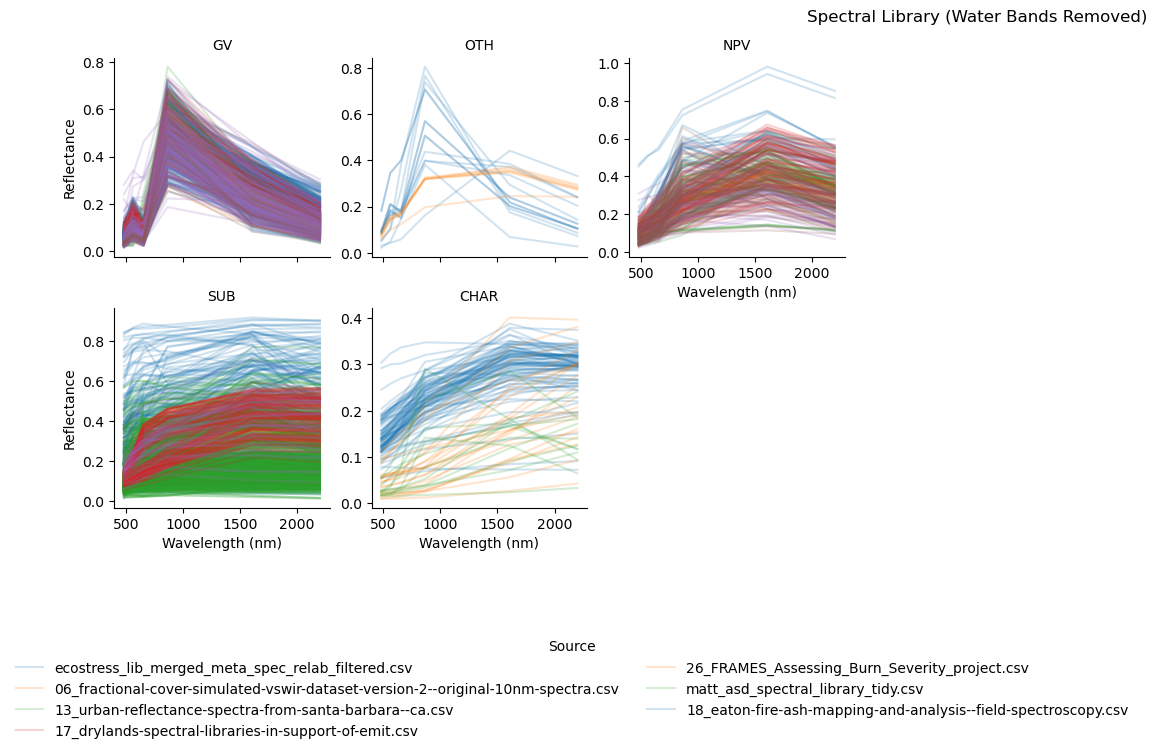

In [13]:

# --- reshape like pivot_longer ---
meta_cols = ["class", "category_1",	"category_2", "id", "source"]  # include source

wavelength_cols = [c for c in reflectance_resampled.columns if str(c).replace(".", "").isdigit()]

df_long = reflectance_resampled.melt(
    id_vars=meta_cols,
    value_vars=wavelength_cols,
    var_name="wavelength",
    value_name="reflectance"
)

df_long["wavelength"] = pd.to_numeric(df_long["wavelength"], errors="coerce")

# --- plotting ---
g = sns.FacetGrid(df_long, col="class", col_wrap=3, sharey=False, sharex=True)
g.map_dataframe(
    sns.lineplot,
    x="wavelength",
    y="reflectance",
    hue="source",      # color by source
    units="id",        # separate lines per spectrum
    estimator=None,    # raw lines
    alpha=0.2          # slight transparency
)

g.set_axis_labels("Wavelength (nm)", "Reflectance")
g.set_titles("{col_name}")

# Move legend to the bottom
g.add_legend(title="Source", bbox_to_anchor=(0.3, -0.05), loc="upper center", ncol=2)
plt.subplots_adjust(top=0.9, bottom=0.15)
g.fig.suptitle("Spectral Library (Water Bands Removed)")
plt.show()


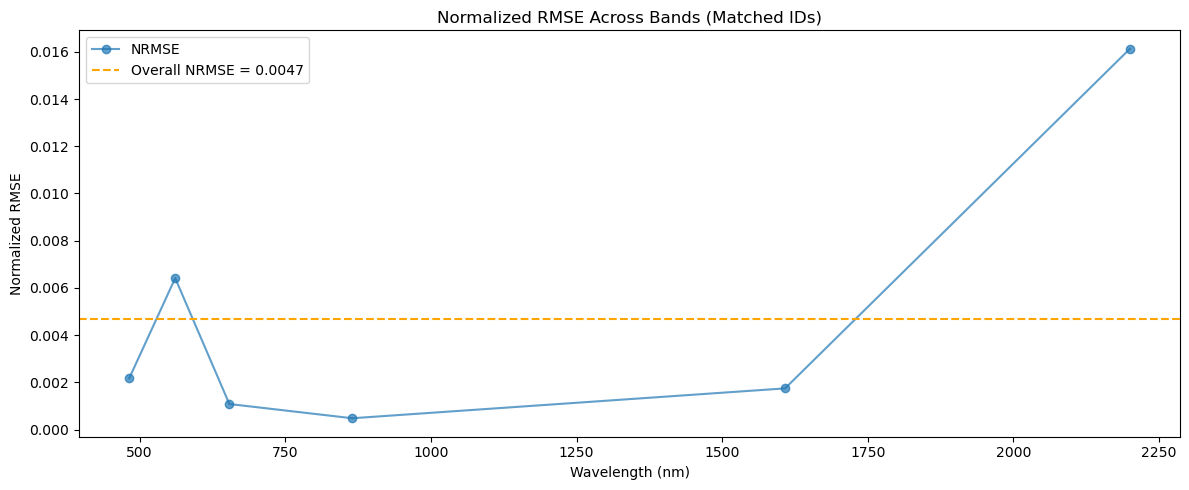

In [14]:
# Find numeric wavelength columns in spectral_lib
spectral_lib_wavelength_cols = [c for c in spectral_lib.columns if str(c).replace(".", "").replace("-", "").isdigit()]

#Convert to float for matching 
reflectance_resampled_wls = np.array([float(w) for w in wavelength_cols]) 
spec_lib_wls = np.array([float(w) for w in spectral_lib_wavelength_cols]) 
# For each reflectance_resampled wavelength, find the closest in spectral_lib 
closest_spec_lib_cols = [spectral_lib_wavelength_cols[np.argmin(np.abs(spec_lib_wls - w))] for w in reflectance_resampled_wls]


# Find matching ids 
matching_ids = list(set(reflectance_resampled['id']).intersection(set(spectral_lib['id'])))
# Filter both DataFrames to matching ids 
reflectance_resampled_matched = reflectance_resampled[reflectance_resampled['id'].isin(matching_ids)].set_index('id')
spectral_lib_matched = spectral_lib[spectral_lib['id'].isin(matching_ids)].set_index('id')


# Calculate NRMSE per band
nrmse_per_band = []
for out_col, spec_col in zip(wavelength_cols, closest_spec_lib_cols):
    arr1 = reflectance_resampled_matched.loc[matching_ids, out_col].astype(float).values
    arr2 = spectral_lib_matched.loc[matching_ids, spec_col].astype(float).values
    
    # Compute RMSE
    rmse = np.sqrt(np.nanmean((arr1 - arr2)**2))
    
    # Normalize by range of reference (min-max)
    range_ref = np.nanmax(arr2) - np.nanmin(arr2)
    nrmse = rmse / range_ref if range_ref != 0 else np.nan
    nrmse_per_band.append(nrmse)

# Overall NRMSE across all bands
overall_nrmse = np.nanmean(nrmse_per_band)

# Plot NRMSE per band
plt.figure(figsize=(12, 5))
plt.plot(sorted([float(w) for w in closest_spec_lib_cols]), nrmse_per_band, marker='o', linestyle='-', alpha=0.7, label="NRMSE")
plt.axhline(overall_nrmse, color='orange', linestyle='--', label=f"Overall NRMSE = {overall_nrmse:.4f}")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized RMSE")
plt.ticklabel_format(style='plain', axis='y')
plt.title("Normalized RMSE Across Bands (Matched IDs)")
plt.legend()
plt.tight_layout()
plt.show()


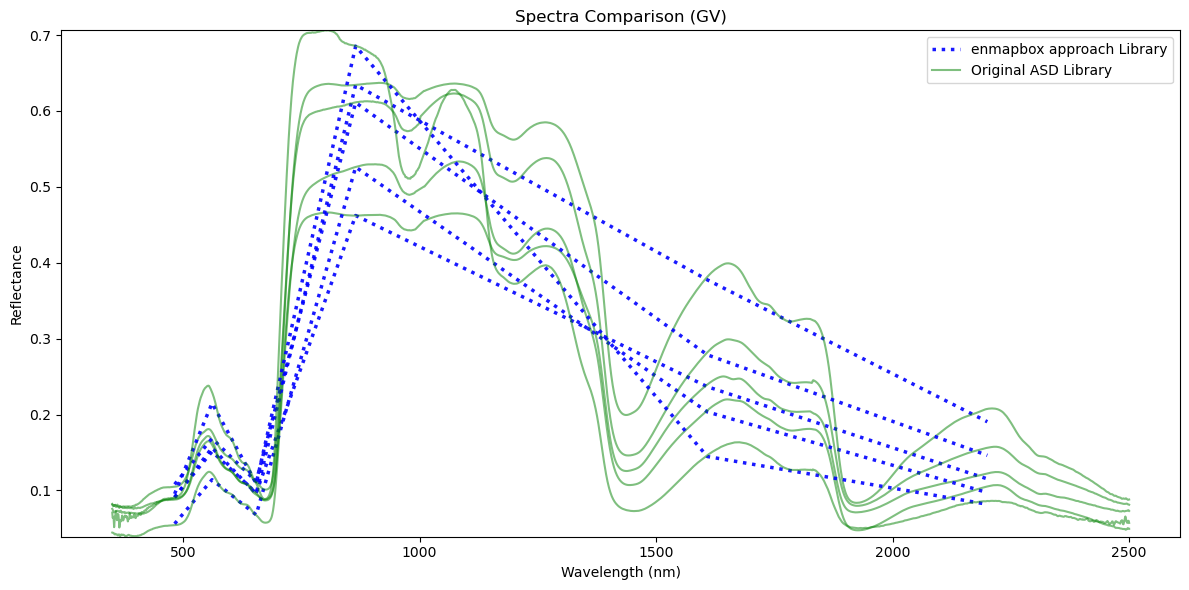

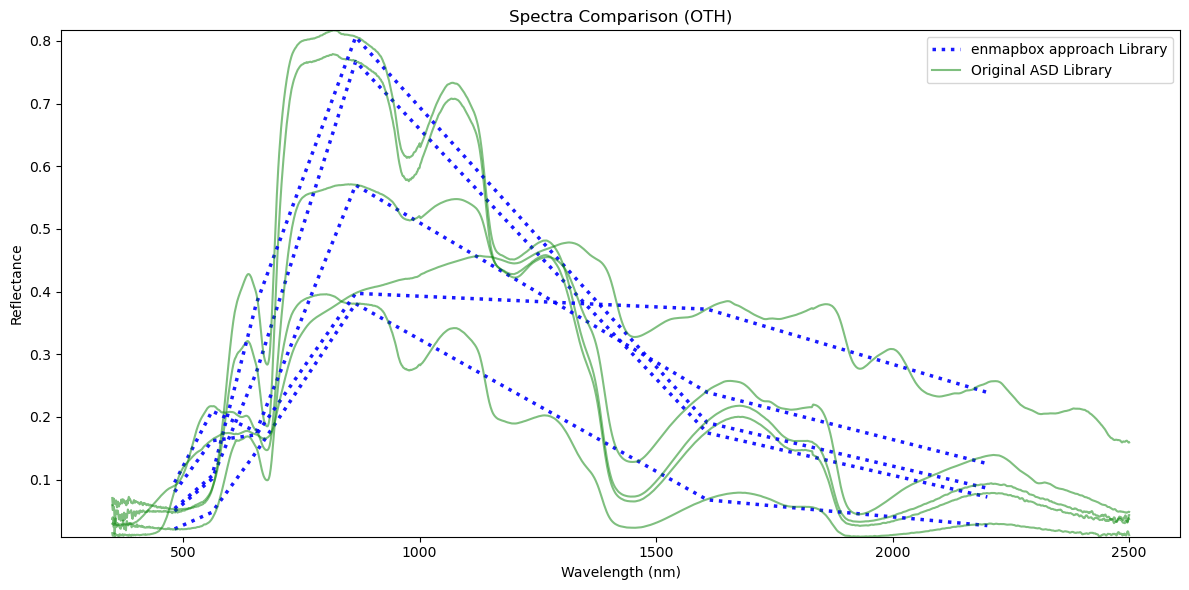

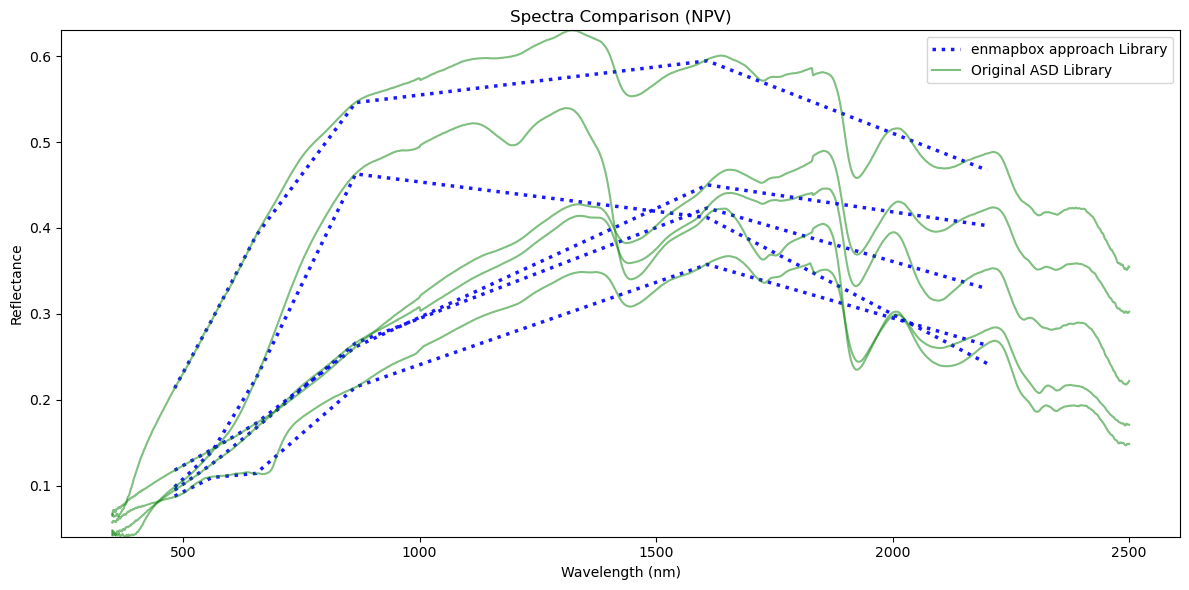

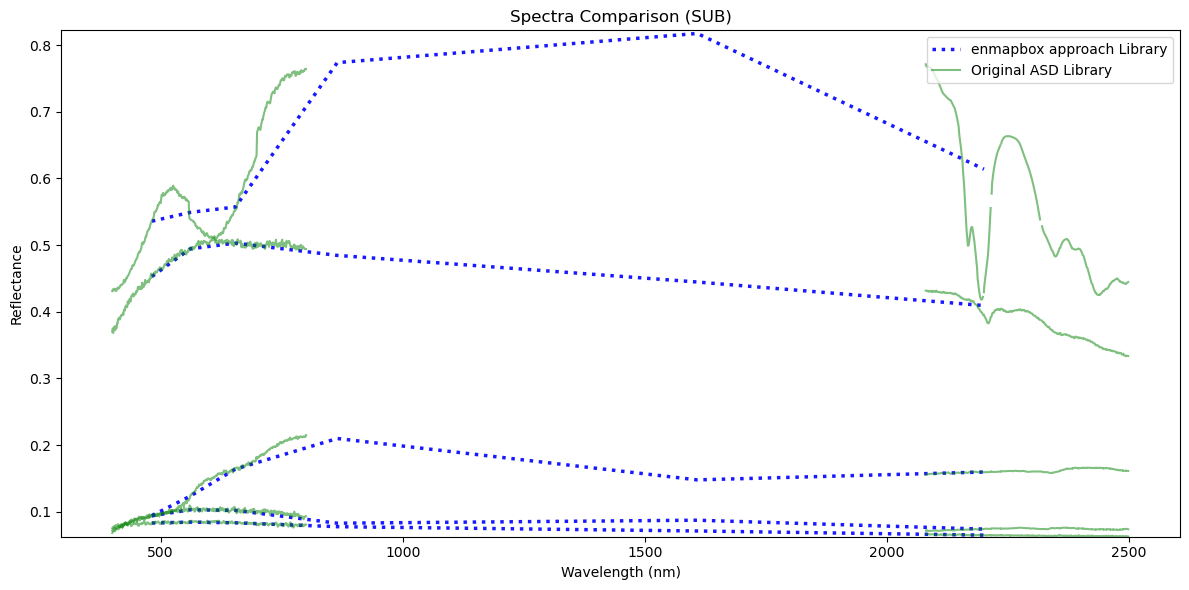

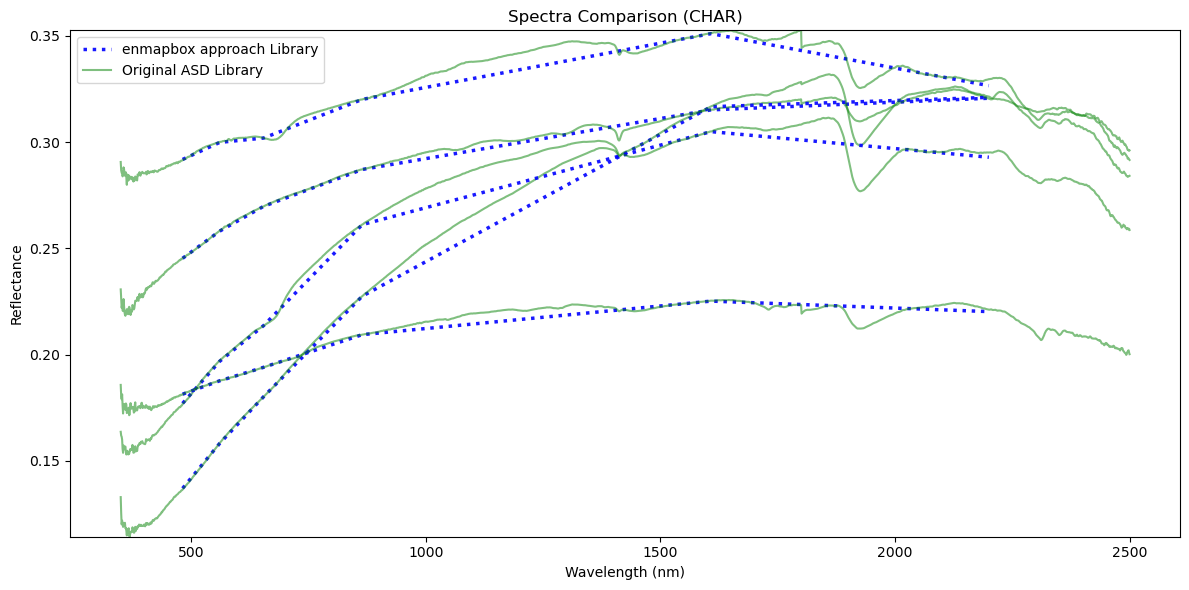

In [15]:
# Define band centers as floats
wavelength_cols = [float(x) for x in wavelength_cols]

# Loop through each class and plot spectra
classes = reflectance_resampled['class'].unique()

for cls in classes:
    # Pick up to 5 spectra per class that exist in matching_ids
    cls_ids = reflectance_resampled.loc[reflectance_resampled['class'] == cls, 'id']
    cls_matching_ids = [i for i in cls_ids if i in matching_ids][:5]
    
    if not cls_matching_ids:
        continue

    plt.figure(figsize=(12, 6))
    all_vals = []

    for sid in cls_matching_ids:
        # Get reflectance (EnMAP resampled)
        spec1 = (
            reflectance_resampled.set_index('id')
            .loc[sid, wavelength_cols]   # <- use floats directly
            .astype(float)
            .values
        )

        plt.plot(wavelength_cols, spec1, alpha=0.9, linestyle=':', color="blue", linewidth=2.5)

        # Get ASD library spectrum
        spec3 = (
            spectral_lib.set_index('id')
            .loc[sid, [str(int(w)) for w in wavelengths]]
            .astype(float)
            .values
        )

        plt.plot(wavelengths, spec3, alpha=0.5, linestyle='-', color='green', linewidth=1.5)
        
        all_vals.extend(spec1)
        all_vals.extend(spec3)

    plt.legend(["enmapbox approach Library", "Original ASD Library"])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Reflectance")
    plt.title(f"Spectra Comparison ({cls})")
    plt.ylim(np.nanmin(all_vals), np.nanmax(all_vals))
    plt.tight_layout()
    plt.show()

